In [113]:
#import libraries 
import numpy as np
import pandas as pd

# **# 1. EDA**

In [114]:
df = pd.read_csv("data/FastagFraudDetection.csv")
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


In [115]:
#shape of data
df.shape

(5000, 13)

In [116]:
#information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Transaction_ID         5000 non-null   int64
 1   Timestamp              5000 non-null   str  
 2   Vehicle_Type           5000 non-null   str  
 3   FastagID               4451 non-null   str  
 4   TollBoothID            5000 non-null   str  
 5   Lane_Type              5000 non-null   str  
 6   Vehicle_Dimensions     5000 non-null   str  
 7   Transaction_Amount     5000 non-null   int64
 8   Amount_paid            5000 non-null   int64
 9   Geographical_Location  5000 non-null   str  
 10  Vehicle_Speed          5000 non-null   int64
 11  Vehicle_Plate_Number   5000 non-null   str  
 12  Fraud_indicator        5000 non-null   str  
dtypes: int64(4), str(9)
memory usage: 507.9 KB


In [117]:
#chcek for null values
df.isnull().sum()

Transaction_ID             0
Timestamp                  0
Vehicle_Type               0
FastagID                 549
TollBoothID                0
Lane_Type                  0
Vehicle_Dimensions         0
Transaction_Amount         0
Amount_paid                0
Geographical_Location      0
Vehicle_Speed              0
Vehicle_Plate_Number       0
Fraud_indicator            0
dtype: int64

In [118]:
df[df['FastagID'].isnull()]

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
9,10,1/15/2023 7:30,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",72,KA22ST6789,Not Fraud
16,17,1/22/2023 16:45,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",62,KA20GH1345,Not Fraud
23,24,1/29/2023 3:05,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",77,KA77UV0123,Not Fraud
30,31,2/5/2023 13:20,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",57,KA92IJ5789,Not Fraud
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4966,4967,8/31/2023 6:08,Motorcycle,NaN,D-106,Regular,Small,0,0,"13.21331620748757, 77.55413526894684",47,AP34MN6789,Not Fraud
4973,4974,12/27/2023 19:04,Motorcycle,NaN,D-106,Regular,Small,0,0,"13.21331620748757, 77.55413526894684",84,AP01AB4567,Not Fraud
4980,4981,4/20/2023 6:01,Motorcycle,NaN,D-106,Regular,Small,0,0,"13.21331620748757, 77.55413526894684",74,AP78OP2345,Not Fraud
4987,4988,8/19/2023 18:57,Motorcycle,NaN,D-106,Regular,Small,0,0,"13.21331620748757, 77.55413526894684",90,AP45CD0123,Not Fraud


In [119]:
df.duplicated().sum()

np.int64(0)

In [120]:
df.describe()  #for numerical features

,Transaction_ID,Transaction_Amount,Amount_paid,Vehicle_Speed
count,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,161.06200,141.261000,67.851200
std,1443.520003,112.44995,106.480996,16.597547
min,1.000000,0.00000,0.000000,10.000000
25%,1250.750000,100.00000,90.000000,54.000000
50%,2500.500000,130.00000,120.000000,67.000000
75%,3750.250000,290.00000,160.000000,82.000000
max,5000.000000,350.00000,350.000000,118.000000


In [121]:
#for numerical+categorical description
df.describe(include='object')

C:\Users\divya\AppData\Local\Temp\ipykernel_20848\1515914048.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Geographical_Location,Vehicle_Plate_Number,Fraud_indicator
count,5000,5000,4451,5000,5000,5000,5000,5000,5000
unique,4423,7,4451,6,2,3,5,5000,2
top,1/24/2023 2:55,Bus,FTG-001-ABC-121,B-102,Regular,Large,"13.059816123454882, 77.77068662374292",KA11AB1234,Not Fraud
freq,5,716,1,1432,2858,2144,1000,1,4017


observation 1: 
1. fastag id has 549 null values
2. no duplicate entries
3. data types are almost correct

In [122]:
df.columns

Index(['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID',
       'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount',
       'Amount_paid', 'Geographical_Location', 'Vehicle_Speed',
       'Vehicle_Plate_Number', 'Fraud_indicator'],
      dtype='str')

In [123]:
#unique values
print("unique vehicle type: ", df['Vehicle_Type'].unique())
print(" ")
print("unique toll booth id: ", df['TollBoothID'].unique())
print(" ")
print("unique lane type: ", df['Lane_Type'].unique())
print(" ")
print("unique vehicle dimensions: ", df['Vehicle_Dimensions'].unique())
print(" ")
print("unique geographical location: ", df['Geographical_Location'].unique())



unique vehicle type:  <StringArray>
['Bus ', 'Car', 'Motorcycle', 'Truck', 'Van', 'Sedan', 'SUV']
Length: 7, dtype: str
 
unique toll booth id:  <StringArray>
['A-101', 'B-102', 'D-104', 'C-103', 'D-105', 'D-106']
Length: 6, dtype: str
 
unique lane type:  <StringArray>
['Express', 'Regular']
Length: 2, dtype: str
 
unique vehicle dimensions:  <StringArray>
['Large', 'Small', 'Medium']
Length: 3, dtype: str
 
unique geographical location:  <StringArray>
['13.059816123454882, 77.77068662374292',
 '13.042660878688794, 77.47580097259879',
  '12.84197701525119, 77.67547528176169',
 '12.936687032945434, 77.53113977439017',
  '13.21331620748757, 77.55413526894684']
Length: 5, dtype: str


# **2. data visualisation**

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

Fraud_indicator
Not Fraud    4017
Fraud         983
Name: count, dtype: int64


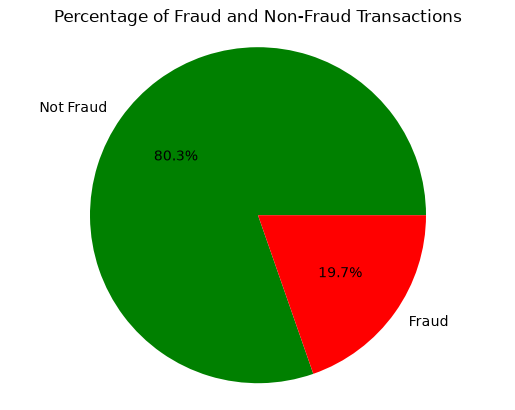

In [154]:
#percentage of fraud and non-fraud transactions
print(df['Fraud_indicator'].value_counts())
df['Fraud_indicator'].value_counts().plot(kind='pie',
                                          autopct='%1.1f%%',
                                          colors=['green', 'red'])
plt.title('Percentage of Fraud and Non-Fraud Transactions')
plt.axis('equal')
plt.show()

analyse different columns

analyse based on fraud indicator

In [155]:
#vehicle types
df['Vehicle_Type'].value_counts()

Vehicle_Type
Bus           716
Car           714
Motorcycle    714
Truck         714
Van           714
Sedan         714
SUV           714
Name: count, dtype: int64

Text(0.5, 1.0, 'Vehicle Type')

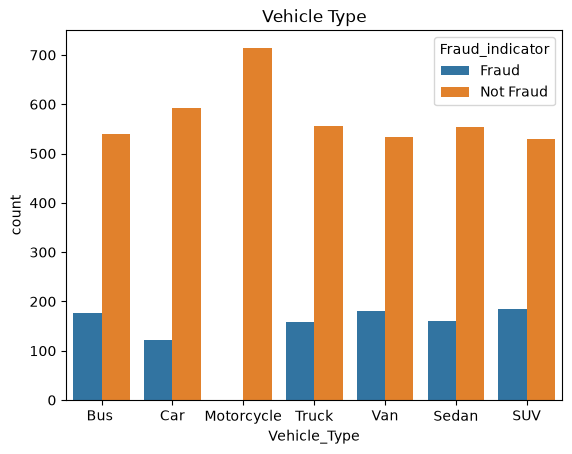

In [156]:
sns.countplot(x='Vehicle_Type', 
              data=df, 
              hue='Fraud_indicator').set_title("Vehicle Type")

Text(0.5, 1.0, 'Vehicle Dimensions')

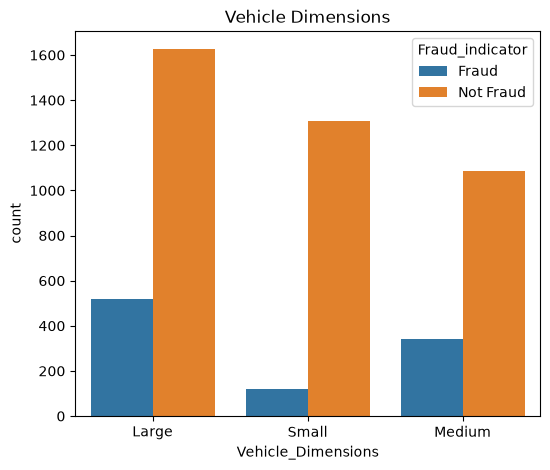

In [157]:
#vehicle dimensions
plt.figure(figsize=(6,5))
sns.countplot(x='Vehicle_Dimensions', 
              data=df, 
              hue='Fraud_indicator').set_title("Vehicle Dimensions")

Text(0.5, 1.0, 'Toll Booth ID')

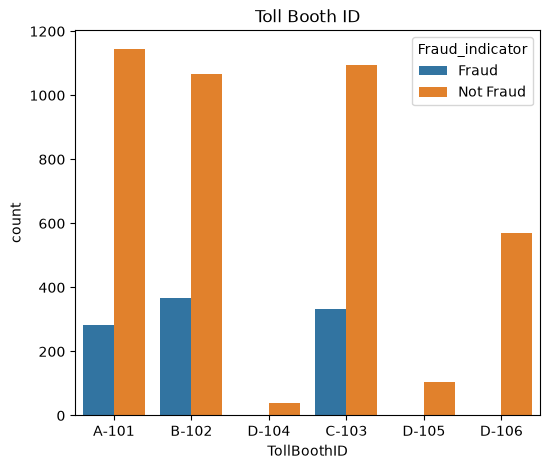

In [158]:
#diferent toll booth id
plt.figure(figsize=(6,5))
sns.countplot(x='TollBoothID', 
              data=df, 
              hue='Fraud_indicator').set_title("Toll Booth ID")

Text(0.5, 1.0, 'Lane Type')

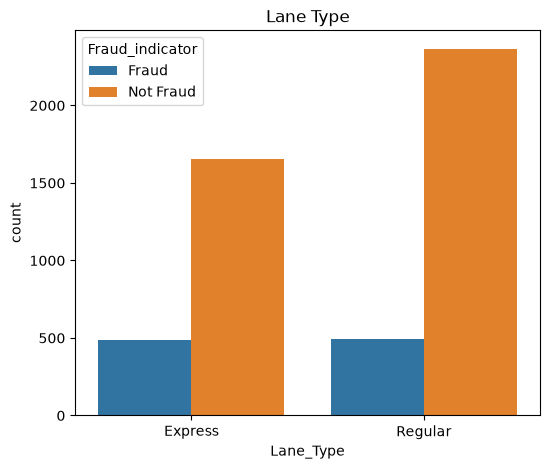

In [159]:
#lane type
plt.figure(figsize=(6,5))
sns.countplot(x='Lane_Type', 
              data=df, 
              hue='Fraud_indicator').set_title("Lane Type")

Text(0.5, 1.0, 'Vehicle Dimensions')

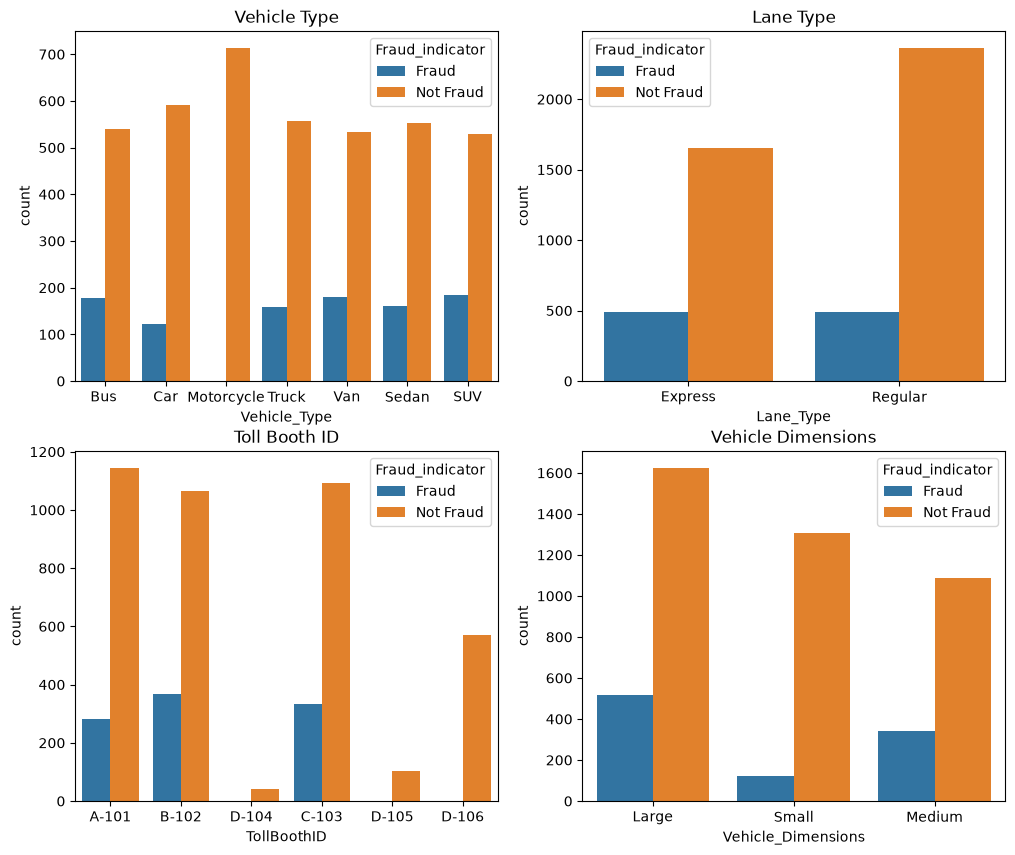

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

In [160]:
#combining all graphs together 
fig, axes = plt.subplots(2,2, figsize=(12,10))

#vehicle type
sns.countplot(x='Vehicle_Type', 
              data=df, 
              hue='Fraud_indicator', ax=axes[0,0]).set_title("Vehicle Type")

#lane type
plt.figure(figsize=(6,5))
sns.countplot(x='Lane_Type', 
              data=df, 
              hue='Fraud_indicator', ax=axes[0,1]).set_title("Lane Type")

#diferent toll booth id
plt.figure(figsize=(6,5))
sns.countplot(x='TollBoothID', 
              data=df, 
              hue='Fraud_indicator', ax=axes[1,0]).set_title("Toll Booth ID")

#vehicle dimensions
plt.figure(figsize=(6,5))
sns.countplot(x='Vehicle_Dimensions', 
              data=df, 
              hue='Fraud_indicator',ax=axes[1,1]).set_title("Vehicle Dimensions")


****observation 

1. motocycles  data are clean , not involved in any fraud.
2. tolllbooths 104, 105, 106 have no fraud detected. but 101,102,103 have mixed data.
3. express way has higher fraud percentage based o vehicles than regular ways.
4. very less small vehicles are involved in fraud.****

**distribution of transaction amount**

In [161]:
df.columns

Index(['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID',
       'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount',
       'Amount_paid', 'Geographical_Location', 'Vehicle_Speed',
       'Vehicle_Plate_Number', 'Fraud_indicator'],
      dtype='str')

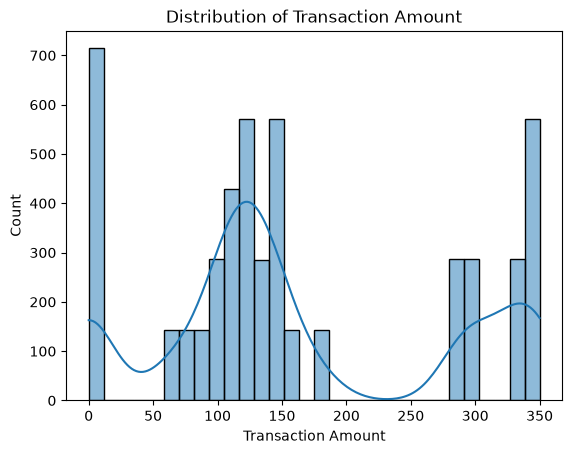

In [162]:
sns.histplot(df['Transaction_Amount'], bins=30, kde=True )
plt.title("Distribution of Transaction Amount")
plt.xlabel('Transaction Amount')
plt.ylabel ("Count")
plt.show()

**distribution of pay amount**

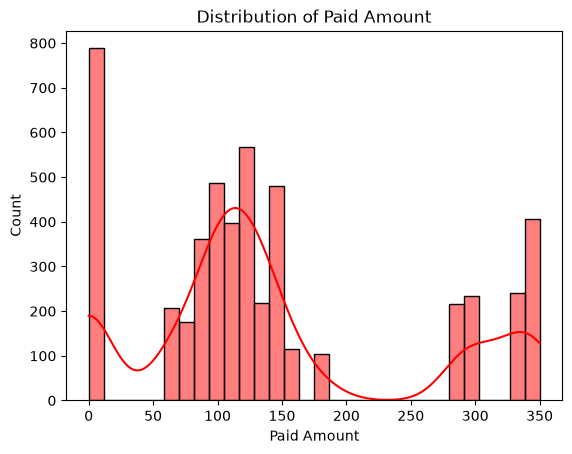

In [163]:
sns.histplot(df['Amount_paid'], bins=30, kde=True, color='red', edgecolor='black' )
plt.title("Distribution of Paid Amount")
plt.xlabel('Paid Amount')
plt.ylabel ("Count")
plt.show()


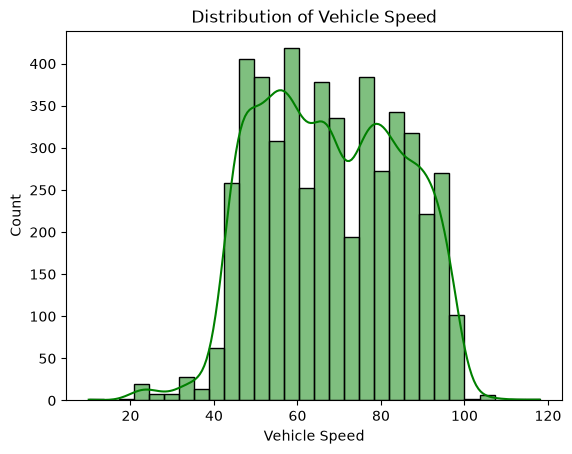

In [164]:
sns.histplot(df['Vehicle_Speed'], bins=30, kde=True, color='green', edgecolor='black' )
plt.title("Distribution of Vehicle Speed")
plt.xlabel('Vehicle Speed')
plt.ylabel ("Count")
plt.show()

**relationship between transaction amount and paid amount**

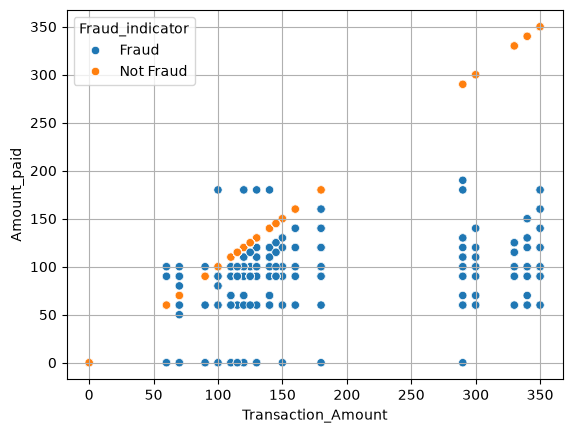

In [165]:
sns.scatterplot(x='Transaction_Amount', 
                y='Amount_paid', 
                data=df, 
                hue='Fraud_indicator')
plt.grid(True)

OBSERAVTION :
1. when transaction amount is not equal to amount paid ==> fraud
2. when transaction amount is equal to amount paid ==> not fraud

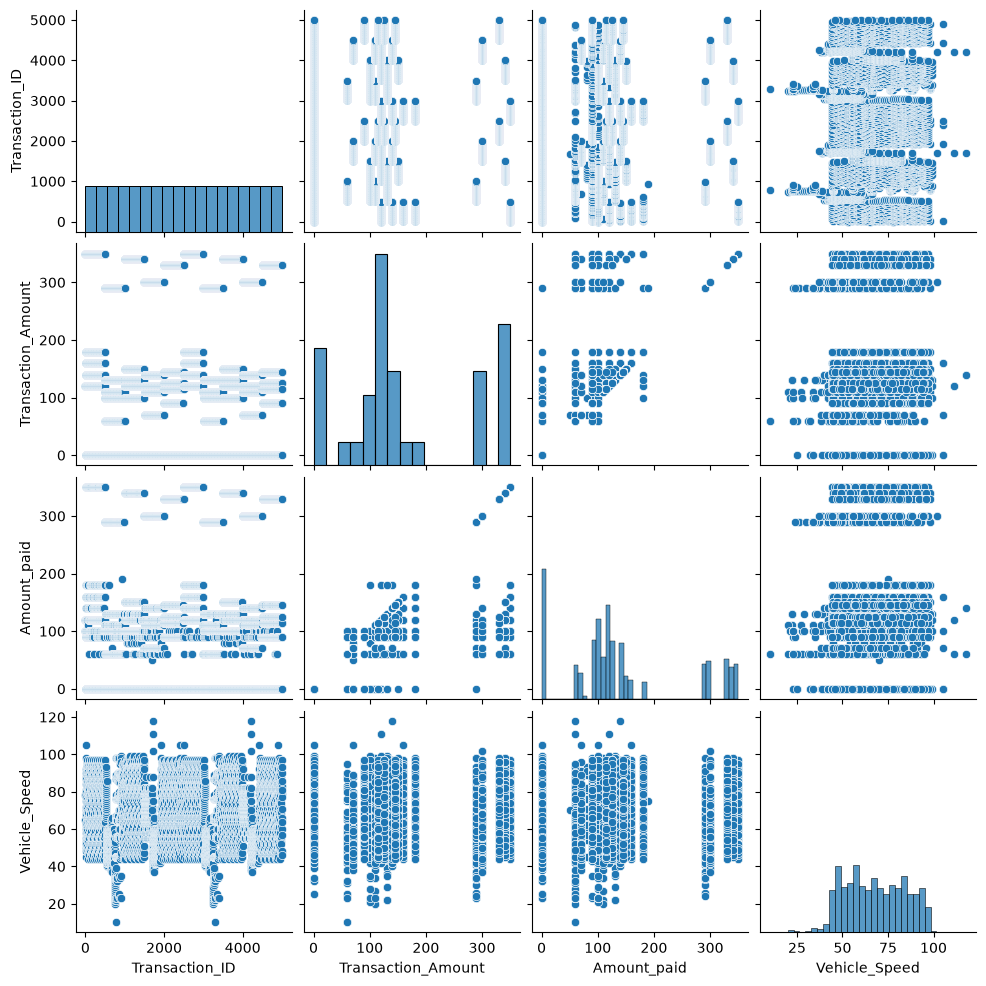

In [166]:
sns.pairplot(df)

**# 3. FEATURE EXTRACTION**

In [168]:
df.isnull().sum()

Transaction_ID             0
Timestamp                  0
Vehicle_Type               0
FastagID                 549
TollBoothID                0
Lane_Type                  0
Vehicle_Dimensions         0
Transaction_Amount         0
Amount_paid                0
Geographical_Location      0
Vehicle_Speed              0
Vehicle_Plate_Number       0
Fraud_indicator            0
dtype: int64

In [169]:
df['FastagID'].mode()[0]

'FTG-000-QAZ-210'

In [173]:
df['State_code']=df['Vehicle_Plate_Number'].str[:2]
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator,State_code
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud,KA
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud,KA
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud,KA
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud,KA
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud,KA


In [174]:
#remove vehicle number plate feature

df=df.drop('Vehicle_Plate_Number', axis=1)

In [175]:
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,State_code
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud,KA
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud,KA
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud,KA
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud,KA
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud,KA


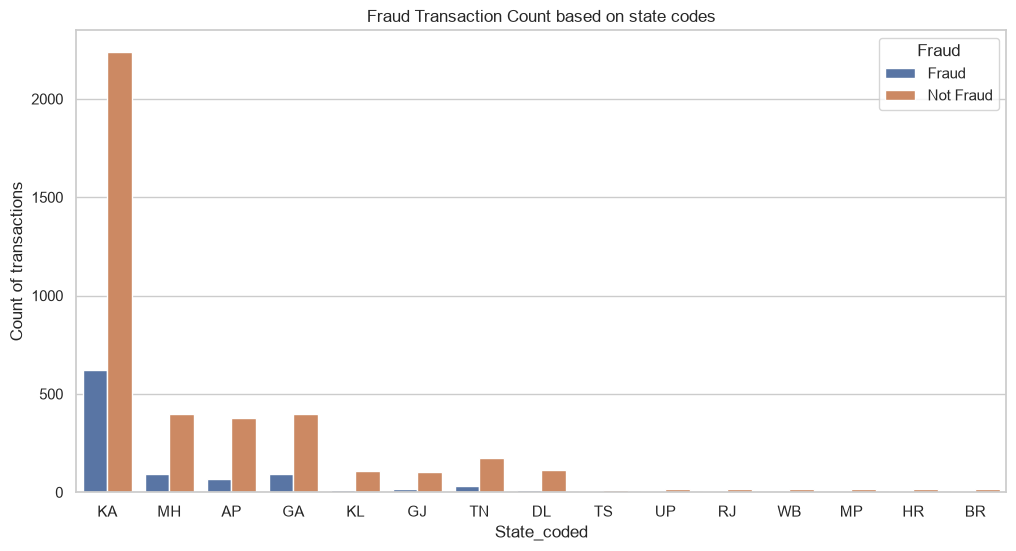

In [ ]:
#visualise fraud based on states
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,6)) 

sns.countplot(x='State_code',
              data=df, 
              hue='Fraud_indicator')

plt.title('Fraud Transaction Count based on state codes')
plt.xlabel('State_coded')
plt.ylabel ("Count of transactions")

plt.legend(title='Fraud')
plt.show()

In [182]:
df['State_code'].value_counts()

State_code
KA    2860
GA     489
MH     488
AP     447
TN     203
DL     123
KL     121
GJ     119
TS      22
UP      22
RJ      22
WB      21
MP      21
HR      21
BR      21
Name: count, dtype: int64

In [183]:
df.loc[df['Fraud_indicator']=='Fraud', 'State_code'].value_counts()

State_code
KA    623
GA     93
MH     92
AP     68
TN     31
GJ     16
KL     14
DL     12
TS      8
RJ      7
BR      6
HR      5
UP      4
WB      2
MP      2
Name: count, dtype: int64

#observation :

1. highest fraud count is in karnatka

In [186]:
#analyse timestamp to get the fraud / not fraud based on days

df['Timestamp']

0        1/6/2023 11:20
1        1/7/2023 14:55
2        1/8/2023 18:25
3         1/9/2023 2:05
4        1/10/2023 6:35
             ...       
4995     1/1/2023 22:18
4996    1/17/2023 13:43
4997      2/5/2023 5:08
4998    2/20/2023 20:34
4999     3/10/2023 0:59
Name: Timestamp, Length: 5000, dtype: str

In [188]:
#convert timestamp into dataframe
df['Timestamp']=pd.to_datetime(df['Timestamp'] )


In [189]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Transaction_ID         5000 non-null   int64         
 1   Timestamp              5000 non-null   datetime64[us]
 2   Vehicle_Type           5000 non-null   str           
 3   FastagID               4451 non-null   str           
 4   TollBoothID            5000 non-null   str           
 5   Lane_Type              5000 non-null   str           
 6   Vehicle_Dimensions     5000 non-null   str           
 7   Transaction_Amount     5000 non-null   int64         
 8   Amount_paid            5000 non-null   int64         
 9   Geographical_Location  5000 non-null   str           
 10  Vehicle_Speed          5000 non-null   int64         
 11  Fraud_indicator        5000 non-null   str           
 12  State_code             5000 non-null   str           
dtypes: datetime64[

In [192]:
df['Hour']=df['Timestamp'].dt.hour
df['DayOfWeek']=df['Timestamp'].dt.day_of_week
df['Month']=df['Timestamp'].dt.month

In [193]:
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,State_code,Hour,DayOfWeek,Month
0,1,2023-01-06 11:20:00,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud,KA,11,4,1
1,2,2023-01-07 14:55:00,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud,KA,14,5,1
2,3,2023-01-08 18:25:00,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud,KA,18,6,1
3,4,2023-01-09 02:05:00,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud,KA,2,0,1
4,5,2023-01-10 06:35:00,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud,KA,6,1,1


In [194]:
df['DayOfWeek'].value_counts()

DayOfWeek
6    743
1    728
0    716
4    713
5    709
2    697
3    694
Name: count, dtype: int64

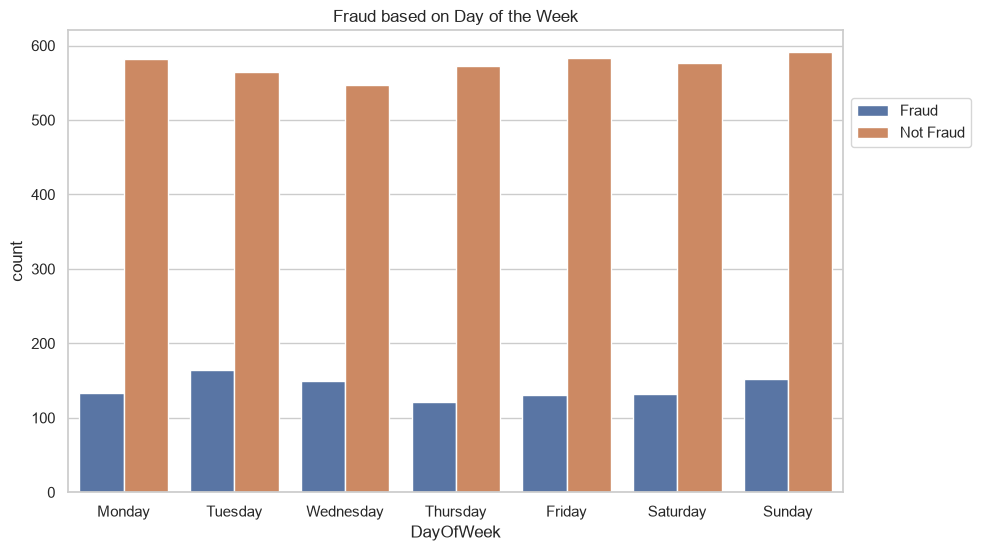

In [200]:
#visulaise based on days of the week
plt.figure(figsize=(10,6))
sns.countplot(x='DayOfWeek',
              data=df, hue='Fraud_indicator').set_title("Fraud based on Day of the Week")

plt.xticks([0,1,2,3,4,5,6], ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.8))
plt.show()

CORRELATION MATRIX

In [202]:
numericaldf=df.select_dtypes('number')

In [206]:
corrmatrix=numericaldf.corr()
corrmatrix

,Transaction_ID,Transaction_Amount,Amount_paid,Vehicle_Speed,Hour,DayOfWeek,Month
Transaction_ID,1.000000,-0.023515,0.044433,0.014378,-0.023208,0.002446,0.260075
Transaction_Amount,-0.023515,1.000000,0.870078,0.053229,-0.036980,-0.001813,-0.019824
Amount_paid,0.044433,0.870078,1.000000,0.039027,-0.026358,-0.002960,0.018105
Vehicle_Speed,0.014378,0.053229,0.039027,1.000000,-0.002259,-0.017608,0.015349
Hour,-0.023208,-0.036980,-0.026358,-0.002259,1.000000,-0.010292,0.001041
DayOfWeek,0.002446,-0.001813,-0.002960,-0.017608,-0.010292,1.000000,0.002552
Month,0.260075,-0.019824,0.018105,0.015349,0.001041,0.002552,1.000000


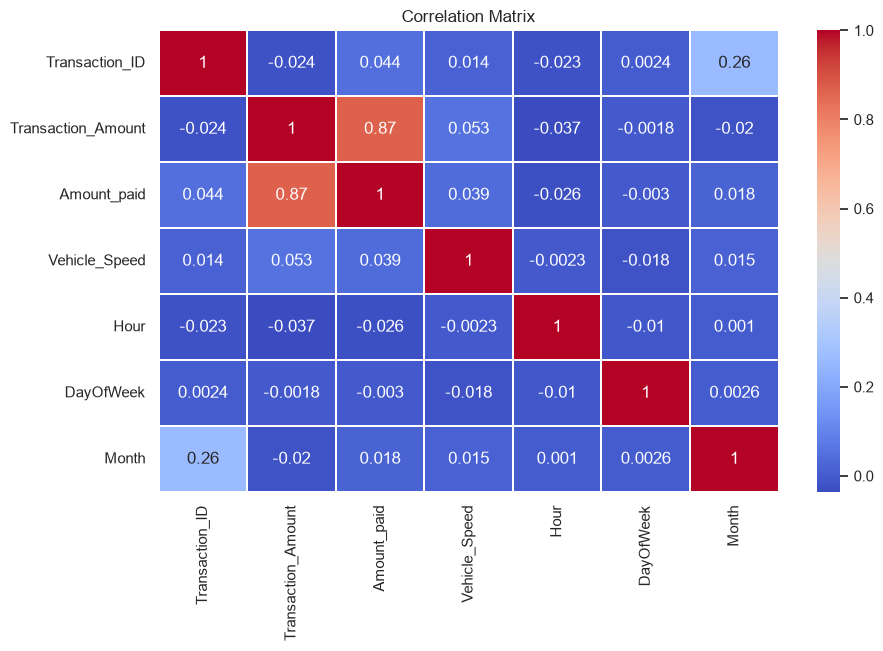

In [211]:
#plot correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(corrmatrix, annot=True, cmap='coolwarm', linewidths=0.2)
plt.title("Correlation Matrix")
plt.show()